<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/WEEKLY_REPORT_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
#load the data
from google.colab import files
uploaded=files.upload()

Saving iiot_30min_norm.csv to iiot_30min_norm.csv


In [4]:
import io

# Assuming the uploaded file is a CSV and its name is in uploaded.keys()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
print("Prévia dos dados:\n", df.head())

Prévia dos dados:
                         TIME       FM1       PE1       PE2       PE3  \
0  2020-07-05 21:00:00+00:00  0.291841  0.944212  0.969845  0.909817   
1  2020-07-05 21:30:00+00:00  0.290384  0.947971  0.971459  0.913576   
2  2020-07-05 22:00:00+00:00  0.279458  0.944138  0.968994  0.912516   
3  2020-07-05 22:30:00+00:00  0.288927  0.950337  0.976253  0.915991   
4  2020-07-05 23:00:00+00:00  0.299610  0.950226  0.975747  0.916188   

        PE4       TP1       TP2       EPOCH  
0  0.752879  0.128703  0.729592  1593982800  
1  0.753741  0.117572  0.723905  1593984600  
2  0.753187  0.111242  0.720671  1593986400  
3  0.756699  0.102464  0.716186  1593988200  
4  0.756563  0.093201  0.711454  1593990000  


In [6]:
# Select only numerical columns for scaling
numerical_cols = df.select_dtypes(include=np.number).columns
X = df[numerical_cols]

# Padronizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# Aplicar PCA (mantendo 2 componentes principais)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [8]:
# Reconstruir os dados a partir dos componentes principais
X_reconstructed = pca.inverse_transform(X_pca)

In [9]:
# Calcular métricas de erro entre os dados originais e reconstruídos
mae = mean_absolute_error(X_scaled, X_reconstructed)
rmse = np.sqrt(mean_squared_error(X_scaled, X_reconstructed))
r2 = r2_score(X_scaled, X_reconstructed)
print("=== Avaliação da Reconstrução PCA ===")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

=== Avaliação da Reconstrução PCA ===
MAE  = 0.4320
RMSE = 0.7096
R²   = 0.4965


In [10]:
explained_variance = pca.explained_variance_ratio_
print("\nVariância explicada por componente:", explained_variance)
print("Variância explicada total:", explained_variance.sum())


Variância explicada por componente: [0.28668503 0.20978444]
Variância explicada total: 0.49646946512456047


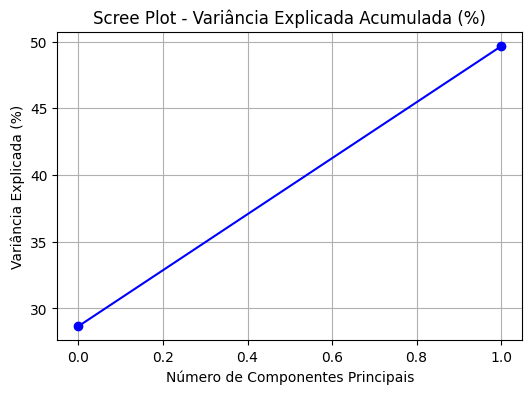

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(explained_variance)*100, marker='o', color='b')
plt.title("Scree Plot - Variância Explicada Acumulada (%)")
plt.xlabel("Número de Componentes Principais")
plt.ylabel("Variância Explicada (%)")
plt.grid(True)
plt.show()

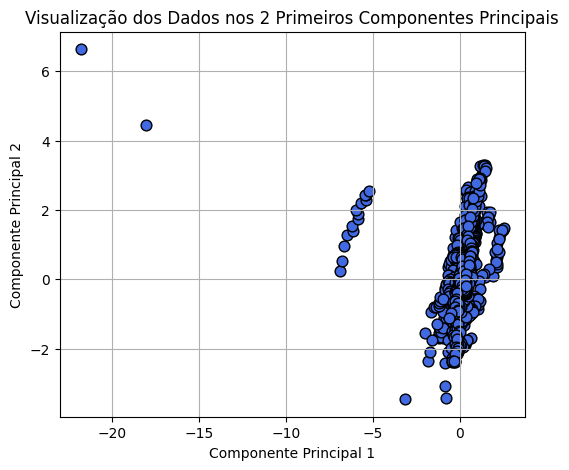

In [12]:
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='royalblue', s=60, edgecolor='black')
plt.title("Visualização dos Dados nos 2 Primeiros Componentes Principais")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.show()

In [13]:
X_reconstructed = pca.inverse_transform(X_pca)

mae = mean_absolute_error(X_scaled, X_reconstructed)
rmse = np.sqrt(mean_squared_error(X_scaled, X_reconstructed))
r2 = r2_score(X_scaled, X_reconstructed)

print("\n=== Avaliação da Reconstrução PCA ===")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")


=== Avaliação da Reconstrução PCA ===
MAE  = 0.4320
RMSE = 0.7096
R²   = 0.4965



Matriz de correlação entre variáveis e componentes:
             PC1       PC2
FM1   -0.349898 -0.125142
PE1   -0.343287  0.066482
PE2   -0.010701  0.139245
PE3    0.568179 -0.161632
PE4    0.579555 -0.294641
TP1    0.226963  0.656123
TP2    0.218391  0.506802
EPOCH -0.041155  0.400308


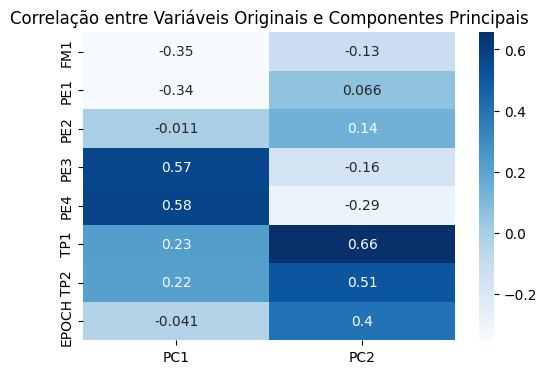

In [17]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)
print("\nMatriz de correlação entre variáveis e componentes:\n", loadings)

plt.figure(figsize=(6,4))
sns.heatmap(loadings, annot=True, cmap='Blues', cbar=True)
plt.title("Correlação entre Variáveis Originais e Componentes Principais")
plt.show()